### **테슬라의 시가를 예측해보자**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler

In [110]:
df = pd.read_csv(r'D:\hanyeowon\Coding\pythonworks\deep\data\TSLA.csv')
df

,Date,Open,High,Low,Close,Adj Close,Volume
0,2010-06-29,3.800000,5.000000,3.508000,4.778000,4.778000,93831500
1,2010-06-30,5.158000,6.084000,4.660000,4.766000,4.766000,85935500
2,2010-07-01,5.000000,5.184000,4.054000,4.392000,4.392000,41094000
3,2010-07-02,4.600000,4.620000,3.742000,3.840000,3.840000,25699000
4,2010-07-06,4.000000,4.000000,3.166000,3.222000,3.222000,34334500
...,...,...,...,...,...,...,...
2951,2022-03-18,874.489990,907.849976,867.390015,905.390015,905.390015,33408500
2952,2022-03-21,914.979980,942.849976,907.090027,921.159973,921.159973,27327200
2953,2022-03-22,930.000000,997.859985,921.750000,993.979980,993.979980,35289500
2954,2022-03-23,979.940002,1040.699951,976.400024,999.109985,999.109985,40225400


In [111]:
scaler = MinMaxScaler()

data = scaler.fit_transform(
    df[['Open']]
)
print(data)
print(type(data))
print(data.shape)

[[4.64594174e-04]
 [1.56759922e-03]
 [1.43926727e-03]
 ...
 [7.52749776e-01]
 [7.93312423e-01]
 [8.17508664e-01]]
<class 'numpy.ndarray'>
(2956, 1)


In [112]:
train_data, test_data = data[:2500], data[2500:]


In [113]:
print(train_data.shape)

(2500, 1)


In [114]:
print(test_data.shape)

(456, 1)


In [58]:
def make_sample(data, window):
    train = []
    target = []
    for i in range(len(data)-window):
        train.append(data[i:i+window])
        target.append(data[i+window])
    return np.array(train), np.array(target)

In [137]:
window_size = 10
train_x, train_y = make_sample(train_data, window_size)
test_x, test_y = make_sample(test_data, window_size)

In [138]:
train_x = train_x.reshape((-1, window_size, 1))
test_x = test_x.reshape((-1, window_size, 1))

In [139]:
print(train_x[0])
print(train_y[0])
print(test_x.shape, test_y.shape)

[[4.64594174e-04]
 [1.56759922e-03]
 [1.43926727e-03]
 [1.11437624e-03]
 [6.27039689e-04]
 [4.22358340e-05]
 [0.00000000e+00]
 [2.33921542e-04]
 [2.94026383e-04]
 [2.03056894e-04]]
[0.0002924]
(446, 10, 1) (446, 1)


In [140]:
import tensorflow.keras
from tensorflow.keras import models, layers

model = models.Sequential()
model.add(layers.SimpleRNN(window_size, activation='tanh', input_shape=(window_size, 1)))
model.add(layers.Dense(1, activation='tanh'))
model.compile(optimizer='adam', loss='mse')

d:\hanyeowon\Coding\pythonworks\deep\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [141]:
history = model.fit(train_x ,train_y, epochs=100, verbose=1)

Epoch 1/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 7.9785e-05 
Epoch 2/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.0517e-05
Epoch 3/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.0918e-05
Epoch 4/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.0415e-05
Epoch 5/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.0298e-05
Epoch 6/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 9.3412e-06
Epoch 7/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 9.5401e-06
Epoch 8/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 9.4965e-06
Epoch 9/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 8.8813e-06
Epoch 10/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 8.7198e-06
Epoch 11/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 8.1929e-06
Epoch 12/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 8.0754e-06
Epoch 13/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7.4878e-06
Epoch 14/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7.3773e-06
Epoch 15/100
7

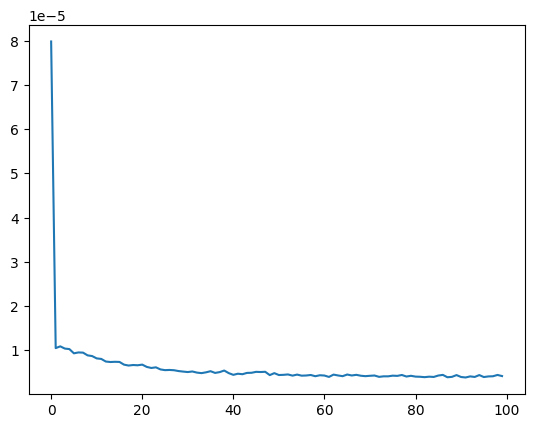

In [142]:
plt.plot(history.history['loss'], label='loss')
plt.show()

In [143]:
pred = model.predict(test_x)


14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


In [144]:
pred

array([[0.15824631],
       [0.16065049],
       [0.16184151],
       [0.1610545 ],
       [0.16128817],
       [0.15830208],
       [0.1543838 ],
       [0.15970032],
       [0.15515204],
       [0.16188286],
       [0.17271799],
       [0.19486642],
       [0.20270908],
       [0.22245117],
       [0.2238111 ],
       [0.22367312],
       [0.22351928],
       [0.2636266 ],
       [0.24569322],
       [0.24410199],
       [0.23554762],
       [0.24401218],
       [0.24177301],
       [0.25648832],
       [0.2537496 ],
       [0.26454023],
       [0.22526263],
       [0.2312648 ],
       [0.24008979],
       [0.23779227],
       [0.23508368],
       [0.2380124 ],
       [0.23383209],
       [0.23669946],
       [0.23642227],
       [0.23754165],
       [0.23772892],
       [0.22998297],
       [0.22384302],
       [0.23357303],
       [0.25512376],
       [0.26125112],
       [0.26287973],
       [0.29803723],
       [0.2925415 ],
       [0.29202807],
       [0.31826395],
       [0.331

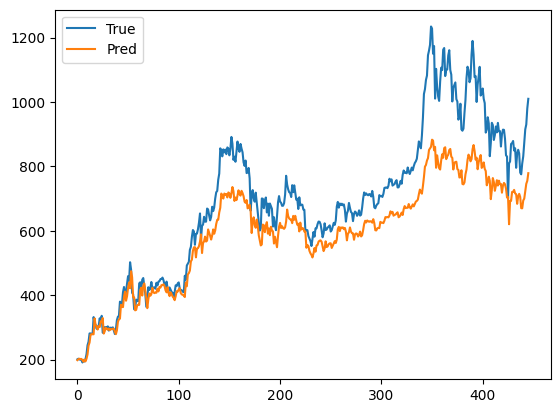

In [145]:
pred = scaler.inverse_transform(pred)
test_y = scaler.inverse_transform(test_y.reshape(-1,1))
plt.plot(test_y, label='True')
plt.plot(pred, label='Pred')
plt.legend(); plt.show()